## 6 — MRdeeP
Multivariate Multilevel Regression with Deep Generative Post-Stratification  

Pipeline:
1. `insert_data` — encodes survey + benchmark, builds augmented benchmark proportional to ACS population weights  
2. `fit` — trains an ensemble of CGANs (Wasserstein loss with gradient penalty)  
3. `post_stratify('state_fips')` — generates synthetic micro-data for every demographic cell, groups by state → `happening_bin` estimates extracted

In [1]:
# Install PyTorch (CPU) if needed — MRdeeP uses it as the deep-learning backend
%pip install torch --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Force PyTorch backend (mlx not installed in this env)
import os
os.environ["DEEPVERSE_BACKEND"] = "pytorch"

# Add the MRdeeP package to the path
sys.path.insert(0, "/Users/carmenk/Documents/CSS/Capstone/mrdeep/python")
from mrdeep import MRdeeP

DATA_DIR = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/test_data/processed/"

### 1. Load and prepare data

In [3]:
survey_raw = pd.read_csv(DATA_DIR + "climate_survey_responses_recoded.csv",
                         dtype={"state_fips": str, "county_fips": str})
ps_frame   = pd.read_csv(DATA_DIR + "poststrat_state.csv",
                         dtype={"state_fips": str})

# ── Demographic variables shared between survey and benchmark ─────────────────
DEMOG_VARS = ["gender", "race4", "educ_category", "county_fips", "state_fips"]

OUTCOME_COLS = [c for c in survey_raw.columns if c.endswith("_bin")]
print(f"Survey raw:    {survey_raw.shape}")
print(f"Outcome cols:  {len(OUTCOME_COLS)} binary outcomes")
print(f"Poststrat:     {ps_frame.shape} | {ps_frame['state_fips'].nunique()} states")

Survey raw:    (1200, 42)
Outcome cols:  30 binary outcomes
Poststrat:     (1632, 9) | 51 states


In [4]:
# ── Survey: keep only rows with no NaN in any outcome, select cols ────────────
survey = (
    survey_raw[DEMOG_VARS + OUTCOME_COLS]
    .dropna()
    .copy()
)
survey["educ_category"] = survey["educ_category"].astype(str)

# ── Benchmark: county-level poststrat frame (~99k cells) ──────────────────────
# Using county × demographic cells exposes MRdeeP to the full sub-state
# geographic variation before aggregation — post_stratify("state_fips") then
# rolls up county-level synthetic individuals to state via population weights.
ps_county = pd.read_csv(DATA_DIR + "poststrat_county.csv",
                        dtype={"state_fips": str, "county_fips": str})
benchmark = ps_county[DEMOG_VARS + ["N_rounded"]].copy()
benchmark["educ_category"] = benchmark["educ_category"].astype(str)
target_rows = len(benchmark)               # ~99k; count ∝ cell population
benchmark["count"] = np.maximum(
    1,
    (benchmark["N_rounded"] / benchmark["N_rounded"].sum() * target_rows).round()
).astype(int)
benchmark = benchmark.drop(columns=["N_rounded"])

print(f"Survey (complete cases): {len(survey):,}  "
      f"({survey['happening_bin'].mean()*100:.1f}% believe GW is happening)")
print(f"Benchmark: {len(benchmark):,} strata (county-level) | "
      f"count range [{benchmark['count'].min()}, {benchmark['count'].max()}]")
print(f"Augmented benchmark rows (oversample=1): {benchmark['count'].sum():,}")

Survey (complete cases): 26  (61.5% believe GW is happening)
Benchmark: 99,940 strata (county-level) | count range [1, 217]
Augmented benchmark rows (oversample=1): 170,690


### 2. Insert data into MRdeeP

In [5]:
mod = MRdeeP(ensembles=3, random_state=42)

mod.insert_data(
    survey    = survey,
    benchmark = benchmark,
    demog_vars = DEMOG_VARS,
    count_col  = "count",
    oversample = 1,     # augmented benchmark already sized; no further multiplication
)
print(mod)

MRdeeP (backend=pytorch, ensembles=3)
  Data inserted: True
  Survey: 26 obs, 30 substantive vars, 5 demographic vars
  Augmented benchmark: 170690 rows
  Fitted: False


### 3. Train CGAN ensemble
Default architecture: 4 × 256-neuron hidden layers, Wasserstein loss + gradient penalty.  
`patience=50` stops early if validation generator loss stops improving.

In [6]:
mod.fit(
    epochs       = 500,
    patience     = 50,
    batch_size   = 256,
    k            = 32,
    print_runtime = True,
)
print(mod)

Ensemble 1/3
Ensemble 2/3
Ensemble 3/3
Total fit time: 47.7 seconds.
MRdeeP (backend=pytorch, ensembles=3)
  Data inserted: True
  Survey: 26 obs, 30 substantive vars, 5 demographic vars
  Augmented benchmark: 170690 rows
  Fitted: True
    Noise dim (k): 32
    Ensemble members: 3
    Generated survey: 170690 rows
    Total fit time: 47.7s


### 4. Post-stratify → state-level estimates for all 30 outcomes

In [7]:
estimates = mod.post_stratify(levels="state_fips")

print(f"Estimates shape: {estimates.shape}  "
      f"({estimates['state_fips'].nunique()} states × {len(OUTCOME_COLS)} outcomes)")
estimates[["state_fips", "happening_bin"]].head(10)

Estimates shape: (51, 31)  (51 states × 30 outcomes)


,state_fips,happening_bin
0,01,0.469891
1,02,0.469836
2,04,0.468146
3,05,0.472631
4,06,0.468756
5,08,0.471667
6,09,0.470345
7,10,0.465200
8,11,0.479210
9,12,0.470060


### 5. Extract `happening_bin` and add state names

In [8]:
STATE_NAMES = {
    '01':'Alabama','02':'Alaska','04':'Arizona','05':'Arkansas','06':'California',
    '08':'Colorado','09':'Connecticut','10':'Delaware','11':'District of Columbia',
    '12':'Florida','13':'Georgia','15':'Hawaii','16':'Idaho','17':'Illinois',
    '18':'Indiana','19':'Iowa','20':'Kansas','21':'Kentucky','22':'Louisiana',
    '23':'Maine','24':'Maryland','25':'Massachusetts','26':'Michigan',
    '27':'Minnesota','28':'Mississippi','29':'Missouri','30':'Montana',
    '31':'Nebraska','32':'Nevada','33':'New Hampshire','34':'New Jersey',
    '35':'New Mexico','36':'New York','37':'North Carolina','38':'North Dakota',
    '39':'Ohio','40':'Oklahoma','41':'Oregon','42':'Pennsylvania',
    '44':'Rhode Island','45':'South Carolina','46':'South Dakota',
    '47':'Tennessee','48':'Texas','49':'Utah','50':'Vermont',
    '51':'Virginia','53':'Washington','54':'West Virginia','55':'Wisconsin',
    '56':'Wyoming',
}

result = estimates[["state_fips", "happening_bin"]].rename(
    columns={"happening_bin": "happening_estimate"}
)
result["state_name"] = result["state_fips"].map(STATE_NAMES)
result = result.sort_values("happening_estimate", ascending=False).reset_index(drop=True)

print(f"National mean estimate: {result['happening_estimate'].mean():.3f}")
print("\nTop 10:"); print(result.head(10).to_string(index=False))
print("\nBottom 10:"); print(result.tail(10).to_string(index=False))

National mean estimate: 0.471

Top 10:
state_fips  happening_estimate           state_name
        11            0.479210 District of Columbia
        32            0.475827               Nevada
        23            0.474037                Maine
        49            0.473010                 Utah
        27            0.472720            Minnesota
        05            0.472631             Arkansas
        40            0.472459             Oklahoma
        53            0.472259           Washington
        42            0.472118         Pennsylvania
        34            0.472069           New Jersey

Bottom 10:
state_fips  happening_estimate     state_name
        46            0.469418   South Dakota
        25            0.468831  Massachusetts
        06            0.468756     California
        26            0.468359       Michigan
        33            0.468290  New Hampshire
        44            0.468169   Rhode Island
        04            0.468146        Arizona
        1

### 6. Visualise

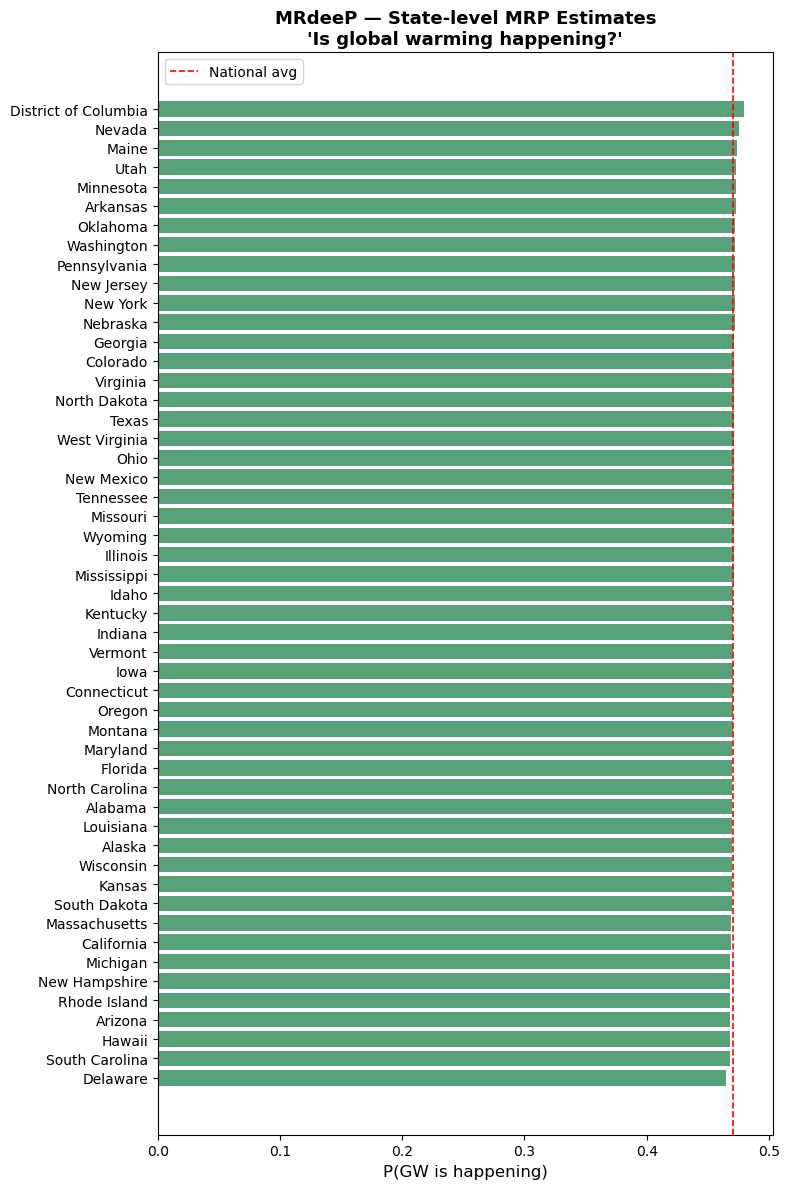

In [9]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = result.sort_values("happening_estimate")
ax.barh(plot_df["state_name"], plot_df["happening_estimate"], color="seagreen", alpha=0.8)
ax.axvline(result["happening_estimate"].mean(), color="red",
           linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("MRdeeP — State-level MRP Estimates\n'Is global warming happening?'",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 7. Save results

In [10]:
OUT = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/mrdeep_state_estimates.csv"
result[["state_fips", "state_name", "happening_estimate"]].rename(columns={"happening_estimate":"estimate"}).to_csv(OUT, index=False)
print(f"Saved → {OUT}")
print(result[["state_fips", "state_name", "happening_estimate"]].to_string(index=False))

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/outputs/estimates/mrdeep_state_estimates.csv
state_fips           state_name  happening_estimate
        11 District of Columbia            0.479210
        32               Nevada            0.475827
        23                Maine            0.474037
        49                 Utah            0.473010
        27            Minnesota            0.472720
        05             Arkansas            0.472631
        40             Oklahoma            0.472459
        53           Washington            0.472259
        42         Pennsylvania            0.472118
        34           New Jersey            0.472069
        36             New York            0.471923
        31             Nebraska            0.471837
        13              Georgia            0.471769
        08             Colorado            0.471667
        51             Virginia            0.471651
        38         North Dakota            0.471646
      